In [ ]:
# Exercise 2.1: Generate 200 fake "brown dwarfs": temperatures uniform in [300, 1300] K, radii uniform in [0.6, 1.3] R_Jup, using np.random. No loops allowed.
import numpy as np

dwarf_temps = np.random.uniform(low=300, high=1300, size=200)
dwarf_radii = np.random.uniform(low=0.6, high=1.3, size=200)

full_data = np.column_stack((dwarf_temps, dwarf_radii))


[[7.91035821e+02 9.08427202e-01]
 [6.12145663e+02 1.03483363e+00]
 [1.13237204e+03 7.48113808e-01]
 [1.21908332e+03 1.10029777e+00]
 [1.15424602e+03 9.50530267e-01]
 [4.47648728e+02 1.19921411e+00]
 [8.99370808e+02 1.24394060e+00]
 [1.06358263e+03 1.27092636e+00]
 [9.09317305e+02 7.61577332e-01]
 [7.03390989e+02 9.02844077e-01]
 [1.25740182e+03 7.24576722e-01]
 [3.39117702e+02 9.83665975e-01]
 [1.05528276e+03 1.08685294e+00]
 [1.11514678e+03 1.17382003e+00]
 [4.25169970e+02 6.39674306e-01]
 [9.81989202e+02 8.13886802e-01]
 [6.18794543e+02 1.26136141e+00]
 [9.81049335e+02 1.26492615e+00]
 [1.01879289e+03 1.14664731e+00]
 [9.63486470e+02 6.12262761e-01]
 [1.09987886e+03 1.20793454e+00]
 [1.01854252e+03 1.04564172e+00]
 [3.28582461e+02 9.58507975e-01]
 [7.86886353e+02 7.53678530e-01]
 [1.20967793e+03 6.57144753e-01]
 [3.08347707e+02 8.47021085e-01]
 [1.14708793e+03 7.33903093e-01]
 [4.64620549e+02 1.29769490e+00]
 [3.81595594e+02 7.45998798e-01]
 [1.29748133e+03 1.03169948e+00]
 [3.832315

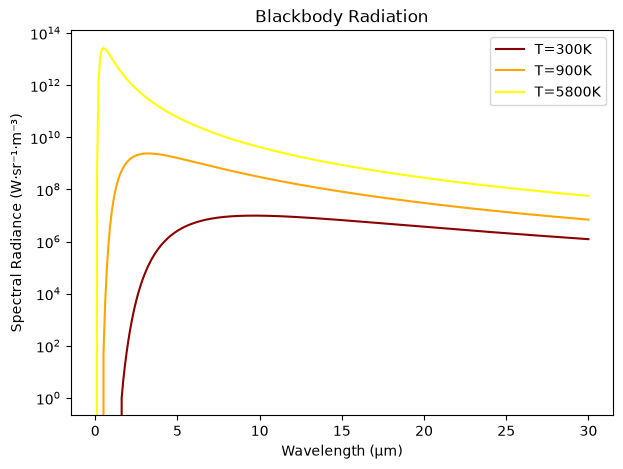

In [4]:
import numpy as np
import math as math
import matplotlib.pyplot as plt


def law_planck(wavelength, T: int):
    #constants needed
    kb = 1.380649E-23 # J-K
    c = 299792458 # m/s
    h = 6.62607015E-34 # J-s

    if wavelength == 0:
        return 0
    section1 = (2 * h * c**2) / (wavelength**5)
    pre_exponent = (h * c) / (wavelength * kb * T)
    section2 = np.exp(pre_exponent) - 1
    if section2 == 0:
        return 0
    return section1 / section2

wavelengths = np.linspace(0, 30E-6, 300)

profile_300 = np.vectorize(lambda x: law_planck(x, 300))(np.copy(wavelengths))
profile_900 = np.vectorize(lambda x: law_planck(x, 900))(np.copy(wavelengths))
profile_5800 = np.vectorize(lambda x: law_planck(x, 5800))(np.copy(wavelengths))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(wavelengths * 1E6, profile_300, label='T=300K', color="darkred")
ax.plot(wavelengths * 1E6, profile_900, label='T=900K', color="orange")
ax.plot(wavelengths * 1E6, profile_5800, label='T=5800K', color="yellow")

ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Spectral Radiance (W·sr⁻¹·m⁻³)")
ax.set_title("Blackbody Radiation")
ax.set_yscale("log")
ax.legend()
fig.savefig("spectrum.png", dpi=200)